# Conditional Graph
Conditional fun?

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [3]:
# We now create an AgentState - shared data structure that keeps track of information as your application runs.

class AgentState(TypedDict):
    "Two numbers and an operation"
    number1: int
    number2: int
    operation: str
    result: int

In [31]:
def adder(state: AgentState) -> AgentState:
    """Node for addition"""

    state['result'] = state['number1'] + state['number2']

    return state

def subtractor(state: AgentState) -> AgentState:
    """Node for subtraction"""

    state['result'] = state['number1'] - state['number2']

    return state

def multiplier(state: AgentState) -> AgentState:
    """Node for multiplication"""

    state['result'] = state['number1'] * state['number2']

    return state

def divider(state: AgentState) -> AgentState:
    """Node for division"""

    state['result'] = state['number1'] // state['number2']

    return state

def decide_next_node(state: AgentState) -> AgentState:
    """Node determining the operation and decides the next node"""

    if state['operation'] == '+':
        return 'addition_operation'
    
    elif state['operation'] == '-':
        return 'subtraction_operation'
    
    elif state['operation'] == '*':
        return 'multiplication_operation'
    
    elif state['operation'] == '/':
        return 'division_operation'

In [38]:
graph = StateGraph(AgentState)

graph.add_node('adder_node', adder)
graph.add_node('subber_node', subtractor)
graph.add_node('multer_node', multiplier)
graph.add_node('divider_node', divider)
graph.add_node('router', lambda state: state)  # passthrough function

graph.add_edge(START, 'router')

graph.add_conditional_edges(
    'router',
    decide_next_node,
    {
        'addition_operation': 'adder_node',
        'subtraction_operation': 'subber_node',
        'multiplication_operation': 'multer_node',
        'division_operation': 'divider_node',
     }
)

graph.add_edge('adder_node', END)
graph.add_edge('subber_node', END)
graph.add_edge('multer_node', END)
graph.add_edge('divider_node', END)

app = graph.compile()

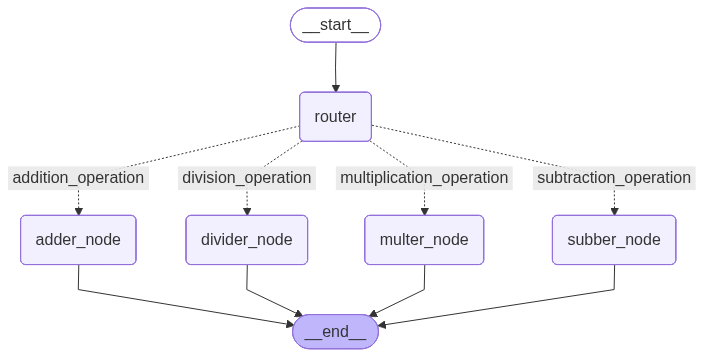

In [39]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [40]:
answer = app.invoke({'number1': 15, 'number2': 21, 'operation': '-'})
print(answer)
print(answer['result'])

{'number1': 15, 'number2': 21, 'operation': '-', 'result': -6}
-6


In [41]:
initial_state_2 = AgentState(number1=15, number2=5, operation='*')
answer = app.invoke(initial_state_2)
print(answer)
print(answer['result'])

{'number1': 15, 'number2': 5, 'operation': '*', 'result': 75}
75


In [42]:
initial_state_3 = AgentState(number1=23, number2=34, operation='+')
answer = app.invoke(initial_state_3)
print(answer)
print(answer['result'])

{'number1': 23, 'number2': 34, 'operation': '+', 'result': 57}
57


In [43]:
initial_state_4 = AgentState(number1=100, number2=8, operation='/')
answer = app.invoke(initial_state_4)
print(answer)
print(answer['result'])

{'number1': 100, 'number2': 8, 'operation': '/', 'result': 12}
12
